In [ ]:
# Install required libraries
!pip install pandas matplotlib seaborn nltk

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

# Download NLTK data for text analysis
nltk.download('punkt')
nltk.download('stopwords')

# Set plot style for better visuals
plt.style.use('ggplot')  # Alternative: 'default' or remove this line



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load the dataset
df = pd.read_csv('raw_analyst_ratings.csv')

# Display basic info
print("Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())
print("\nUnique Stocks:", df['stock'].nunique())
print("Unique Publishers:", df['publisher'].nunique())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 184241 entries, (np.int64(298994), 'CorMedix 8-K Shows Co. Entered Amendment #1 To Registration Rights Deal Between Co. Elliott Associates') to (np.int64(484107), 'Put/Call Ratio Still High on Freeport (FCX)')
Data columns (total 4 columns):
 #   Column                                                                                                            Non-Null Count   Dtype 
---  ------                                                                                                            --------------   ----- 
 0   enzinga.com/news/17/12/10897210/update-cormedix-says-amendment-related-to-when-90-day-period-began-amended-from-  184241 non-null  object
 1   Paul Quintaro                                                                                                     184240 non-null  object
 2   2017-12-11 00:00:00                                                                                               184

KeyError: 'stock'

In [ ]:
# Inspect date column
print("Sample of date column (first 20 rows):")
print(df['date'].head(20))
print("\nUnique date values (sample of 20):")
print(df['date'].sample(20))
print("\nValue counts of date (top 10):")
print(df['date'].value_counts().head(10))

# Check for missing values
print("\nMissing Values:")
print(df.isna().sum())

# Drop Unnamed: 0 column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column")

# Parse dates with flexible handling
def parse_dates(date_str):
    try:
        # Try parsing with pandas (handles ISO8601 and common formats)
        dt = pd.to_datetime(date_str, errors='raise')
        return dt
    except:
        return pd.NaT

# Apply parsing
df['date_clean'] = df['date'].apply(parse_dates)

# Check parsing success
print("\nInvalid dates after parsing:", df['date_clean'].isna().sum())
if df['date_clean'].isna().any():
    print("Sample rows with invalid dates:")
    print(df[df['date_clean'].isna()][['headline', 'date', 'stock']].head(10))
    print("Keeping invalid dates for non-date analyses")

# Standardize timezone to UTC-4 (America/New_York)
def standardize_timezone(dt):
    if pd.isna(dt):
        return dt
    # If no timezone, assume UTC-4 (since dataset is US-focused)
    if dt.tzinfo is None:
        return dt.tz_localize('America/New_York', ambiguous='NaT')
    # If already timezone-aware, convert to UTC-4
    return dt.tz_convert('America/New_York')

df['date_clean'] = df['date_clean'].apply(standardize_timezone)

# Standardize stock tickers and publisher
df['stock'] = df['stock'].str.upper().str.strip()
df['publisher'] = df['publisher'].str.strip()

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Rows after dropping duplicates:", len(df))

# Verify cleaned dataset
print("\nCleaned Dataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# Save cleaned dataset
df.to_csv('fnspid_cleaned.csv', index=False)
from google.colab import files
files.download('fnspid_cleaned.csv')

Sample of date column (first 20 rows):
0     2020-06-05 10:30:54-04:00
1     2020-06-03 10:45:20-04:00
2     2020-05-26 04:30:07-04:00
3     2020-05-22 12:45:06-04:00
4     2020-05-22 11:38:59-04:00
5     2020-05-22 11:23:25-04:00
6     2020-05-22 09:36:20-04:00
7     2020-05-22 09:07:04-04:00
8     2020-05-22 08:37:59-04:00
9     2020-05-22 08:06:17-04:00
10          2020-05-22 00:00:00
11          2020-05-22 00:00:00
12          2020-05-21 00:00:00
13          2020-05-21 00:00:00
14          2020-05-21 00:00:00
15          2020-05-21 00:00:00
16          2020-05-18 00:00:00
17          2020-05-16 00:00:00
18          2020-05-15 00:00:00
19          2020-05-08 00:00:00
Name: date, dtype: object

Unique date values (sample of 20):
796528          2018-01-12 00:00:00
142860          2014-06-30 00:00:00
865188          2010-07-15 00:00:00
604193          2015-02-24 00:00:00
644805    2020-06-09 10:34:41-04:00
712141          2015-11-16 00:00:00
861014          2015-04-20 00:00:00
738193 

Headline Length Statistics (Characters):
count    172.000000
mean      40.331395
std        9.841466
min       29.000000
25%       39.000000
50%       39.000000
75%       42.000000
max      120.000000
Name: headline_char_length, dtype: float64

Headline Length Statistics (Words):
count    172.000000
mean       6.843023
std        1.312917
min        5.000000
25%        7.000000
50%        7.000000
75%        7.000000
max       16.000000
Name: headline_word_length, dtype: float64


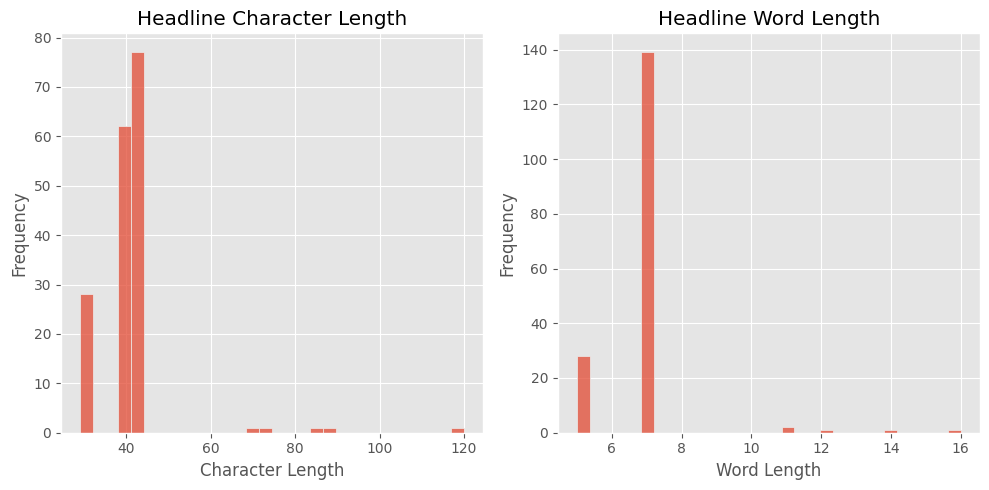

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Calculate headline length (characters and words)
df['headline_char_length'] = df['headline'].apply(len)
df['headline_word_length'] = df['headline'].apply(lambda x: len(x.split()))

# Compute descriptive statistics
print("Headline Length Statistics (Characters):")
print(df['headline_char_length'].describe())
print("\nHeadline Length Statistics (Words):")
print(df['headline_word_length'].describe())

# Plot histogram of headline lengths
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['headline_char_length'], bins=30)
plt.title('Headline Character Length')
plt.xlabel('Character Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['headline_word_length'], bins=30)
plt.title('Headline Word Length')
plt.xlabel('Word Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('headline_length.png')  # Save for GitHub
plt.show()


Top 10 Publishers by Article Count:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


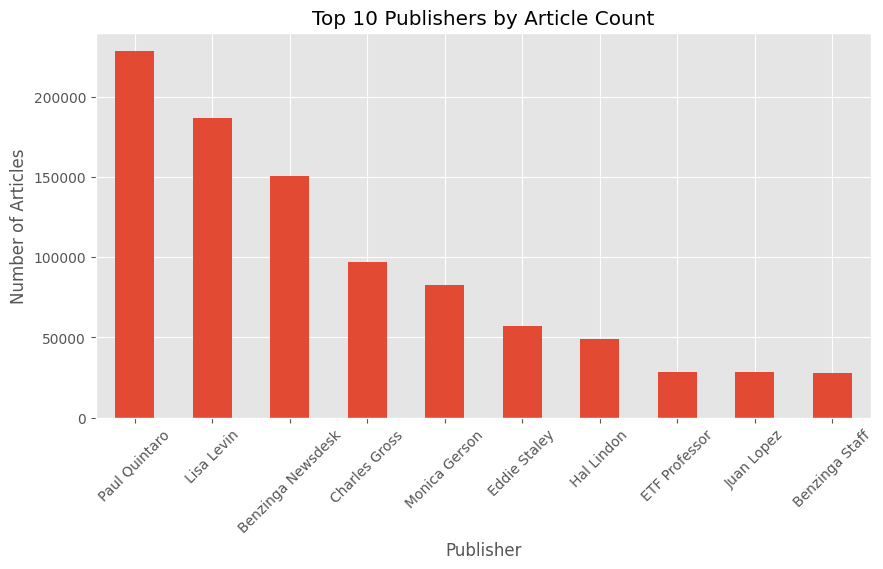

In [ ]:
# Count articles per publisher
publisher_counts = df['publisher'].value_counts()

# Display top 10 publishers
print("Top 10 Publishers by Article Count:")
print(publisher_counts.head(10))

# Plot top 10 publishers
plt.figure(figsize=(10, 5))
publisher_counts.head(10).plot(kind='bar')
plt.title('Top 10 Publishers by Article Count')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Convert date to datetime (handle varying formats without assuming timezone)
df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

# Check for parsing errors
if df['date'].isna().any():
    print("Warning: Some dates failed to parse. Missing dates:", df['date'].isna().sum())
    print("Rows with invalid dates:")
    print(df[df['date'].isna()][['headline', 'date', 'stock']])

# Convert to UTC-4 (America/New_York)
df['date'] = df['date'].dt.tz_localize(None).dt.tz_localize('America/New_York')

# Extract date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

# Count articles by date (daily)
daily_counts = df.groupby(df['date'].dt.date).size()

# Count articles by weekday
weekday_counts = df['weekday'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plot daily publication frequency
plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title('Daily Publication Frequency')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.savefig('daily_publication.png')  # Save for GitHub
plt.show()

# Plot articles by weekday
plt.figure(figsize=(10, 5))
weekday_counts.plot(kind='bar')
plt.title('Articles by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.savefig('weekday_publication.png')  # Save for GitHub
plt.show()

# Save processed dataset
df.to_csv('fnspid_processed.csv', index=False)
from google.colab import files
files.download('fnspid_processed.csv')

<ipython-input-13-61468735e2b7>:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')


AttributeError: Can only use .dt accessor with datetimelike values